# Confidence Intervals vs. Prediction Intervals in Regression

### A Geoscience Worked Example Using Oil Production Data

**Matteo Niccoli** | [mycarta.wordpress.com](https://mycarta.wordpress.com) | matteo@mycarta.ca

---

This notebook demonstrates the critical distinction between **confidence intervals** and **prediction intervals** in the context of Ordinary Least Squares (OLS) regression, using a petroleum geology dataset from [Hunt (2013)](http://csegrecorder.com/features/view/value-of-integrated-geophysics-201312).

Understanding this difference is essential for making sound decisions in exploration and appraisal, where the question is not just *"what is the average production?"* but *"what production should we expect from the next well?"*

## 1. The Key Concepts

### Confidence Interval (CI) for the Mean Response

The confidence interval quantifies our uncertainty about **where the true regression line lies**. Given our limited sample, the estimated regression line is just one of many possible lines we could have obtained. The CI captures this parameter estimation uncertainty.

- Narrower band (less uncertainty)
- Answers: *"For wells with these properties, where does the **average** production lie?"*
- Narrows as sample size increases

### Prediction Interval (PI) for a New Observation

The prediction interval quantifies our uncertainty about **where a new individual observation will fall**. Even if we knew the true regression line perfectly, individual wells would still scatter around it due to natural variability.

- Always wider than the CI (adds residual variance on top of parameter uncertainty)
- Answers: *"What range of production should we expect for the **next well** we drill?"*
- Has an irreducible width (the residual standard error), even with infinite data

### The Mathematical Difference

For a predicted value $\hat{y}_0$ at a given $x_0$:

$$\text{CI}(\hat{y}_0) = \hat{y}_0 \pm t_{\alpha/2,\, n-p}\;\cdot\; \hat{\sigma} \sqrt{x_0^T (X^T X)^{-1} x_0}$$

$$\text{PI}(y_{\text{new}}) = \hat{y}_0 \pm t_{\alpha/2,\, n-p}\;\cdot\; \hat{\sigma} \sqrt{1 + x_0^T (X^T X)^{-1} x_0}$$

The only difference is the **+ 1** under the square root in the PI formula. That extra 1 represents the variance of a single new observation around the mean — the irreducible scatter.

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

## 3. The Dataset

The data comes from **Lee Hunt's (2013)** paper [*Many correlation coefficients, null hypotheses, and high value*](http://csegrecorder.com/features/view/value-of-integrated-geophysics-201312), published in the CSEG Recorder.

It contains measurements from **21 wells** producing from a **marine barrier sand**:

| Variable | Description | Unit |
|---|---|---|
| **Gross pay** | Total thickness of the pay zone | metres |
| **Phi-h** | Porosity × thickness (with 3% porosity cutoff) | porosity-metres |
| **Position** | Ranked position within reservoir (1=upper, 2=middle, 3=lower) | ordinal |
| **Pressure** | Pressure draw-down | MPa |
| **Production** | Oil production rate (the target variable) | tens of bbl/d |

As shown in [Notebook 2 of this series](https://github.com/mycarta/predict/blob/master/Geoscience_ML_notebook_2.ipynb), **Gross pay** is the strongest single predictor of production ($r = 0.87$), while **Position** and **Pressure** have weaker but physically meaningful relationships that warrant their inclusion in a multivariate model.

In [2]:
data = pd.read_csv('Table2_Hunt_2013_edit.csv')
data.index = np.arange(1, len(data) + 1)
data.index.name = 'Well'
data

,Gross pay,Phi-h,Position,Pressure,Random 1,Random 2,Gross pay transform,Production
Well,,,,,,,,
1,0.1,0.5,2.1,19,5,379,3.54,15.10
2,1.0,4.0,1.1,16,13,269,5.79,21.30
3,1.9,19.0,1.0,14,12,245,8.51,22.75
4,3.1,21.7,2.1,17,6,273,11.52,15.72
5,4.1,24.6,2.9,11,10,237,10.16,7.71
6,4.9,39.2,1.1,12,7,278,11.14,22.67
7,5.9,23.6,2.1,13,13,241,15.04,18.11
8,7.0,63.0,2.0,13,20,269,15.10,24.30
9,8.1,72.9,2.9,14,1,248,14.49,24.04


### Quick Data Summary

In [3]:
data[['Gross pay', 'Position', 'Pressure', 'Production']].describe().round(2)

,Gross pay,Position,Pressure,Production
count,21.00,21.00,21.00,21.00
mean,9.82,1.89,15.29,33.43
std,5.95,0.71,2.76,15.14
min,0.10,1.00,10.00,7.71
25%,4.90,1.10,14.00,22.67
50%,10.00,2.00,16.00,36.42
75%,15.10,2.20,17.00,44.20
max,19.10,2.90,20.00,59.20


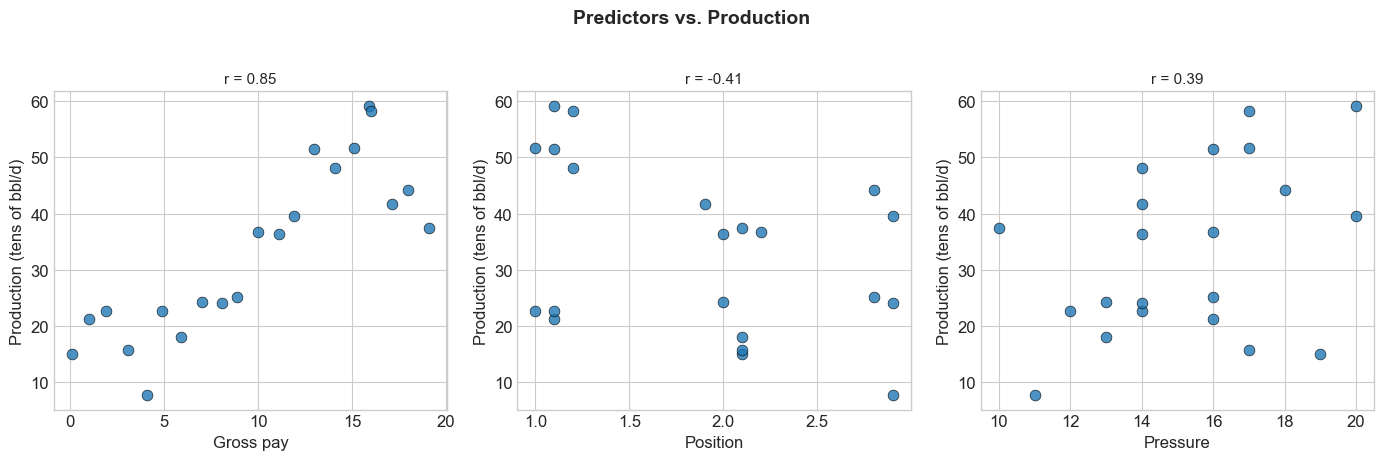

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, var in zip(axes, ['Gross pay', 'Position', 'Pressure']):
    ax.scatter(data[var], data['Production'], s=60, edgecolors='k',
               linewidths=0.5, alpha=0.8)
    ax.set_xlabel(var)
    ax.set_ylabel('Production (tens of bbl/d)')

    # Add correlation coefficient
    r = data[var].corr(data['Production'])
    ax.set_title(f'r = {r:.2f}', fontsize=11)

fig.suptitle('Predictors vs. Production', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Bivariate Case: Production vs. Gross Pay

We start with the simplest case — a single predictor. This makes it easy to visualize and understand the intervals before moving to the multivariate case.

In [5]:
# Prepare data: sort by Gross pay for clean plotting
sort_data = data.sort_values('Gross pay')

X_bi = sort_data[['Gross pay']]
X_bi = sm.add_constant(X_bi, prepend=False)  # add intercept (constant) column
y = sort_data['Production']

# Fit OLS
model_bi = sm.OLS(y, X_bi)
results_bi = model_bi.fit()

print(results_bi.summary())

                            OLS Regression Results                            
Dep. Variable:             Production   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     49.15
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.12e-06
Time:                        10:37:01   Log-Likelihood:                -72.940
No. Observations:                  21   AIC:                             149.9
Df Residuals:                      19   BIC:                             152.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Gross pay      2.1617      0.308      7.011      0.0

### Computing the Intervals

Using `statsmodels`' `get_prediction()` method, we obtain both the **confidence interval** (for the mean) and the **prediction interval** (for individual observations) in a single call:

In [ ]:
pred_bi = results_bi.get_prediction()
pred_bi_df = pred_bi.summary_frame(alpha=0.05)  # 95% intervals

# Default columns: mean, mean_se, mean_ci_lower, mean_ci_upper, obs_ci_lower, obs_ci_upper
# Display with friendlier names
display_df = pred_bi_df.copy()
display_df.columns = ['Predicted', 'SE_mean', 'CI_lower', 'CI_upper',
                       'PI_lower', 'PI_upper']
display_df.round(2)

ValueError: Length mismatch: Expected axis has 6 elements, new values have 7 elements

### Visualizing CI vs. PI

The **inner band** (darker) is the confidence interval for the mean response.
The **outer band** (lighter) is the prediction interval for a new observation.

Notice how both intervals are narrower near the centre of the data (where we have the most information) and widen toward the edges.

In [ ]:
xx = sort_data['Gross pay'].values

fig, ax = plt.subplots(figsize=(10, 7))

# Data points
ax.scatter(xx, y, s=70, zorder=5, edgecolors='k', linewidths=0.5,
           label='Observed (21 wells)', color='#2196F3')

# Regression line
ax.plot(xx, pred_bi_df['mean'], '-', lw=2.5, color='#E53935',
        label='OLS regression line')

# Prediction interval (outer, lighter)
ax.fill_between(xx, pred_bi_df['obs_ci_lower'], pred_bi_df['obs_ci_upper'],
                alpha=0.15, color='#E53935', label='95% Prediction Interval (PI)')

# Confidence interval (inner, darker)
ax.fill_between(xx, pred_bi_df['mean_ci_lower'], pred_bi_df['mean_ci_upper'],
                alpha=0.35, color='#E53935', label='95% Confidence Interval (CI)')

ax.set_xlabel('Gross Pay (m)', fontsize=13)
ax.set_ylabel('Production (tens of bbl/d)', fontsize=13)
ax.set_title('Bivariate Regression: Production vs. Gross Pay\n'
             'with Confidence and Prediction Intervals',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 80)
ax.set_xlim(-0.5, 21)

plt.tight_layout()
plt.show()

## 5. Practical Application: Economic Risk

This is where the PI becomes genuinely useful in geoscience decision-making.

Suppose our **minimum economic production cutoff** is **20 (tens of bbl/d)**. We want to know: *what minimum gross pay should we require before drilling the next well?*

- Using the **regression line alone** (naïve approach): a gross pay of ~3.5 m seems sufficient.
- Using the **prediction interval** (realistic approach): we need a gross pay of ~12 m to ensure a 95% probability that the next well's production exceeds our cutoff.

The difference between 3.5 m and 12 m of required gross pay is enormous in practical terms — it could determine whether a prospect gets drilled or not.

In [ ]:
xx = sort_data['Gross pay'].values
cutoff = 20  # minimum economic production

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(xx, y, s=70, zorder=5, edgecolors='k', linewidths=0.5,
           color='#2196F3', label='Observed (21 wells)')
ax.plot(xx, pred_bi_df['mean'], '-', lw=2.5, color='#E53935',
        label='OLS regression line')
ax.fill_between(xx, pred_bi_df['obs_ci_lower'], pred_bi_df['obs_ci_upper'],
                alpha=0.15, color='#E53935', label='95% Prediction Interval')
ax.fill_between(xx, pred_bi_df['mean_ci_lower'], pred_bi_df['mean_ci_upper'],
                alpha=0.35, color='#E53935', label='95% Confidence Interval')

# Economic cutoff line
ax.axhline(y=cutoff, color='green', lw=2, ls='--', label=f'Economic cutoff = {cutoff}')

# Annotate: regression intersection
ax.annotate('Regression suggests\n~3.5 m gross pay',
            xy=(3.5, cutoff), xytext=(5, 8),
            fontsize=10, fontweight='bold', color='#E53935',
            arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.5))

# Annotate: PI intersection
ax.annotate('PI lower bound suggests\n~12 m gross pay needed',
            xy=(12, cutoff), xytext=(13, 8),
            fontsize=10, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

ax.set_xlabel('Gross Pay (m)', fontsize=13)
ax.set_ylabel('Production (tens of bbl/d)', fontsize=13)
ax.set_title('Economic Risk Assessment Using Prediction Intervals',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, 80)
ax.set_xlim(-0.5, 21)
plt.tight_layout()
plt.show()

## 6. Effect of Sample Size on the Prediction Interval

In early appraisal stages, we may only have a handful of wells. Fewer data points mean wider prediction intervals — and potentially very different conclusions about economic viability.

Below we simulate an early-stage scenario by randomly selecting only **7 of the 21 wells** and repeating the analysis.

In [ ]:
np.random.seed(37)  # reproducible selection
idx_few = np.sort(np.random.choice(range(len(sort_data)), 7, replace=False))

sort_data_few = sort_data.iloc[idx_few]
X_few = sort_data_few[['Gross pay']]
X_few = sm.add_constant(X_few, prepend=False)
y_few = sort_data_few['Production']

model_few = sm.OLS(y_few, X_few)
results_few = model_few.fit()

pred_few = results_few.get_prediction()
pred_few_df = pred_few.summary_frame(alpha=0.05)

xx_few = sort_data_few['Gross pay'].values

# --- Side by side comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, title, xvals, yvals, pdf, n_label in [
    (ax1, '21 Wells (full dataset)', xx, y, pred_bi_df, 21),
    (ax2, '7 Wells (early appraisal)', xx_few, y_few, pred_few_df, 7)]:

    ax.scatter(xvals, yvals, s=70, zorder=5, edgecolors='k',
               linewidths=0.5, color='#2196F3', label=f'Observed ({n_label} wells)')
    ax.plot(xvals, pdf['mean'], '-', lw=2.5, color='#E53935', label='OLS fit')
    ax.fill_between(xvals, pdf['obs_ci_lower'], pdf['obs_ci_upper'],
                    alpha=0.15, color='#E53935', label='95% PI')
    ax.fill_between(xvals, pdf['mean_ci_lower'], pdf['mean_ci_upper'],
                    alpha=0.35, color='#E53935', label='95% CI')
    ax.axhline(y=cutoff, color='green', lw=2, ls='--', label=f'Cutoff = {cutoff}')
    ax.set_xlabel('Gross Pay (m)', fontsize=13)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_ylim(0, 80)
    ax.set_xlim(-0.5, 21)

ax1.set_ylabel('Production (tens of bbl/d)', fontsize=13)
fig.suptitle('Impact of Sample Size on Prediction Intervals',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Width comparison
pi_w_21 = pred_bi_df['obs_ci_upper'].median() - pred_bi_df['obs_ci_lower'].median()
pi_w_7 = pred_few_df['obs_ci_upper'].median() - pred_few_df['obs_ci_lower'].median()
print(f'21 wells  \u2192  PI width at median: {pi_w_21:.1f} (tens of bbl/d)')
print(f' 7 wells  \u2192  PI width at median: {pi_w_7:.1f} (tens of bbl/d)')

### Observations

With only 7 wells:
- The prediction interval is **substantially wider**, reflecting greater uncertainty
- The required minimum gross pay (from the PI lower bound) increases from ~12 m to ~17.5 m
- The regression slope may change, because the specific well selection matters

As Hunt (2013) emphasizes, the key is to **understand the statistics and either accept the uncertainty, or improve conditions** (drill more wells, add seismic data, etc.).

> *"What you get depends on the luck of the draw."*

## 7. Multivariate Case: Adding Position and Pressure

In practice, production depends on more than just pay thickness. The [variable screening in Notebook 2](https://github.com/mycarta/predict/blob/master/Geoscience_ML_notebook_2.ipynb) concluded that **Gross pay, Phi-h, Position, and Pressure** should be retained.

For this demonstration, we use **Gross pay, Position, and Pressure** (dropping Phi-h, which is partially redundant with Gross pay since it contains a thickness term).

Adding physically meaningful predictors should reduce the residual variance, which narrows both the CI and PI.

In [ ]:
# Multivariate OLS: Production ~ Gross pay + Position + Pressure
sort_data_mv = data.sort_values('Gross pay')

X_mv = sort_data_mv[['Gross pay', 'Position', 'Pressure']]
X_mv = sm.add_constant(X_mv, prepend=False)
y_mv = sort_data_mv['Production']

model_mv = sm.OLS(y_mv, X_mv)
results_mv = model_mv.fit()

print(results_mv.summary())

In [ ]:
# Compare model fits
print(f'Bivariate R-squared:    {results_bi.rsquared:.4f}')
print(f'Multivariate R-squared: {results_mv.rsquared:.4f}')
print(f'')
print(f'Bivariate residual SE:    {np.sqrt(results_bi.mse_resid):.2f}')
print(f'Multivariate residual SE: {np.sqrt(results_mv.mse_resid):.2f}')

### Visualizing the Multivariate Intervals

With a multivariate model, we can't simply plot intervals against a single x-axis because the prediction depends on all three variables simultaneously.

**Approach 1: Index-based plot** — plot observations in order of increasing Gross pay, showing how the prediction tracks actual production.

In [ ]:
pred_mv = results_mv.get_prediction()
pred_mv_df = pred_mv.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 7))

idx = np.arange(len(y_mv))

ax.scatter(idx, y_mv, s=70, zorder=5, edgecolors='k', linewidths=0.5,
           color='#2196F3', label='Observed')
ax.plot(idx, pred_mv_df['mean'], '-', lw=2.5, color='#E53935',
        label='Predicted (multivariate OLS)')
ax.fill_between(idx, pred_mv_df['obs_ci_lower'], pred_mv_df['obs_ci_upper'],
                alpha=0.15, color='#E53935', label='95% PI')
ax.fill_between(idx, pred_mv_df['mean_ci_lower'], pred_mv_df['mean_ci_upper'],
                alpha=0.35, color='#E53935', label='95% CI')
ax.axhline(y=cutoff, color='green', lw=2, ls='--', alpha=0.7,
           label=f'Cutoff = {cutoff}')

ax.set_xlabel('Well index (sorted by Gross Pay)', fontsize=13)
ax.set_ylabel('Production (tens of bbl/d)', fontsize=13)
ax.set_title('Multivariate OLS: Production ~ Gross Pay + Position + Pressure',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

**Approach 2: Partial-effect plot** — to visualize intervals against Gross pay, we hold Position and Pressure at their mean values and vary only Gross pay. This shows the *marginal effect* of Gross pay on production.

In [ ]:
# Hold Position and Pressure at their means
X_partial = X_mv.copy()
X_partial['Position'] = X_mv['Position'].mean()
X_partial['Pressure'] = X_mv['Pressure'].mean()

pred_partial = results_mv.get_prediction(X_partial)
pred_partial_df = pred_partial.summary_frame(alpha=0.05)

xx_mv = sort_data_mv['Gross pay'].values
# Add residuals back to show where actual observations fall
y_partial_adjusted = pred_partial_df['mean'] + results_mv.resid

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(xx_mv, y_partial_adjusted, s=70, zorder=5, edgecolors='k',
           linewidths=0.5, color='#2196F3',
           label='Adjusted observed (predicted + residual)')
ax.plot(xx_mv, pred_partial_df['mean'], '-', lw=2.5, color='#E53935',
        label='Partial effect of Gross Pay')
ax.fill_between(xx_mv, pred_partial_df['obs_ci_lower'],
                pred_partial_df['obs_ci_upper'],
                alpha=0.15, color='#E53935', label='95% PI')
ax.fill_between(xx_mv, pred_partial_df['mean_ci_lower'],
                pred_partial_df['mean_ci_upper'],
                alpha=0.35, color='#E53935', label='95% CI')
ax.axhline(y=cutoff, color='green', lw=2, ls='--', alpha=0.7,
           label=f'Cutoff = {cutoff}')

ax.set_xlabel('Gross Pay (m)', fontsize=13)
ax.set_ylabel('Production (tens of bbl/d)', fontsize=13)
ax.set_title('Partial Effect of Gross Pay '
             '(Position & Pressure held at means)\n'
             'with Confidence and Prediction Intervals',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(0, 80)
ax.set_xlim(-0.5, 21)
plt.tight_layout()
plt.show()

## 8. Comparing Bivariate vs. Multivariate Intervals

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# --- Bivariate ---
ax1.scatter(xx, y, s=60, zorder=5, edgecolors='k', linewidths=0.5,
            color='#2196F3', label='Observed')
ax1.plot(xx, pred_bi_df['mean'], '-', lw=2.5, color='#E53935',
         label='OLS fit')
ax1.fill_between(xx, pred_bi_df['obs_ci_lower'], pred_bi_df['obs_ci_upper'],
                 alpha=0.15, color='#E53935', label='95% PI')
ax1.fill_between(xx, pred_bi_df['mean_ci_lower'], pred_bi_df['mean_ci_upper'],
                 alpha=0.35, color='#E53935', label='95% CI')
ax1.axhline(y=cutoff, color='green', lw=2, ls='--', alpha=0.7)
ax1.set_xlabel('Gross Pay (m)', fontsize=13)
ax1.set_ylabel('Production (tens of bbl/d)', fontsize=13)
ax1.set_title(f'Bivariate: Production ~ Gross Pay\n'
              f'$R^2$ = {results_bi.rsquared:.3f},  '
              f'$\hat{{\sigma}}$ = {np.sqrt(results_bi.mse_resid):.2f}',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
ax1.set_ylim(0, 80)
ax1.set_xlim(-0.5, 21)

# --- Multivariate (partial) ---
ax2.scatter(xx_mv, y_partial_adjusted, s=60, zorder=5, edgecolors='k',
            linewidths=0.5, color='#2196F3', label='Adjusted observed')
ax2.plot(xx_mv, pred_partial_df['mean'], '-', lw=2.5, color='#E53935',
         label='Partial fit')
ax2.fill_between(xx_mv, pred_partial_df['obs_ci_lower'],
                 pred_partial_df['obs_ci_upper'],
                 alpha=0.15, color='#E53935', label='95% PI')
ax2.fill_between(xx_mv, pred_partial_df['mean_ci_lower'],
                 pred_partial_df['mean_ci_upper'],
                 alpha=0.35, color='#E53935', label='95% CI')
ax2.axhline(y=cutoff, color='green', lw=2, ls='--', alpha=0.7)
ax2.set_xlabel('Gross Pay (m)', fontsize=13)
ax2.set_title(f'Multivariate: + Position + Pressure\n'
              f'$R^2$ = {results_mv.rsquared:.3f},  '
              f'$\hat{{\sigma}}$ = {np.sqrt(results_mv.mse_resid):.2f}',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_xlim(-0.5, 21)

fig.suptitle('Adding Predictors Narrows the Prediction Interval',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Key Takeaways

1. **Confidence intervals** tell you about the uncertainty in the **average** response. **Prediction intervals** tell you about the uncertainty for the **next individual** observation. They answer fundamentally different questions.

2. **Prediction intervals are always wider** than confidence intervals because they include both parameter uncertainty *and* the residual scatter of individual observations.

3. **Both intervals are widest at the extremes** of the predictor range, where we have the least information to constrain estimates. They are narrowest near the centre of the data.

4. **Sample size matters enormously.** With fewer wells, both intervals widen — but the PI widens more dramatically, potentially changing economic decisions.

5. **Adding physically meaningful predictors narrows the PI** by reducing residual variance. The multivariate model ($R^2 \approx 0.998$ vs. $0.80$) produces substantially tighter intervals, reflecting genuinely better predictions.

6. **In geoscience decision-making, use the PI, not the CI** when assessing risk for the next well. Using only the regression line (or even the CI) dramatically underestimates the uncertainty about individual future observations.

---

### References

1. Hunt, L. (2013). [*Many correlation coefficients, null hypotheses, and high value*](http://csegrecorder.com/features/view/value-of-integrated-geophysics-201312). CSEG Recorder, December 2013.

2. Brown, S. [*Prediction Interval for Responses to a Particular x*](https://brownmath.com/stat/infregr.htm#IndivResp). Stats Without Tears.

3. Penn State STAT 501. [*Prediction Interval for a New Response*](https://newonlinecourses.science.psu.edu/stat501/node/268/). Online course materials.

4. Kalkomey, C. T. (1997). [*Potential risks when using seismic attributes as predictors of reservoir properties*](http://library.seg.org/doi/abs/10.1190/1.1437610). The Leading Edge, March 1997.

5. Barnes, A. E. (2006). [*Too many seismic attributes?*](http://csegrecorder.com/articles/view/too-many-seismic-attributes). CSEG Recorder, March 2006.

6. Perktold, J., Seabold, S., Taylor, J. & statsmodels-developers. [*statsmodels — Linear Regression*](https://www.statsmodels.org/devel/regression.html). statsmodels documentation.

7. Perktold, J. [*OLSResults.get_prediction()*](https://www.statsmodels.org/devel/generated/statsmodels.regression.linear_model.OLSResults.get_prediction.html). statsmodels API Reference — returns `PredictionResults` with confidence and prediction intervals.

8. Perktold, J. [*PredictionResults.summary_frame()*](https://www.statsmodels.org/devel/generated/statsmodels.regression.linear_model.PredictionResults.summary_frame.html). statsmodels API Reference — produces the DataFrame with `mean_ci_lower/upper` (CI) and `obs_ci_lower/upper` (PI) columns used throughout this notebook.

9. Perktold, J. [*Ordinary Least Squares example notebook*](https://www.statsmodels.org/devel/examples/notebooks/generated/ols.html). statsmodels Examples — demonstrates OLS fitting with prediction intervals.